#### Illustration of study region
Region (with buffer): [91, 27, 99, 32]


In [2]:
import geopandas as gpd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import rasterio as rio 
from matplotlib.colors import LinearSegmentedColormap



In [3]:
path_hma_vec = 'data/boundary/TPBoundary_new2021.gpkg'
path_setp_vec = 'data/boundary/setp_zhao2022.gpkg'
# path_setp_rgi70 = 
## dem 
path_srtm = 'data/dem/srtm-c/setp_SRTMGL3_005deg.tif'



In [4]:
## data reading
tp_gdf = gpd.read_file(path_hma_vec)
setp_vec = gpd.read_file(path_setp_vec)
with rio.open(path_srtm) as dem_rio:
    dem_meta = dem_rio.meta
    dem_bounds = dem_rio.bounds
    dem_arr = dem_rio.read(1)
dem_extent = [dem_bounds.left, dem_bounds.right, dem_bounds.bottom, dem_bounds.top]
print(dem_extent) 


[90.99958333327177, 99.49958333327177, 27.000416666673033, 32.00041666667303]


/tmp/ipykernel_1519878/1349877557.py:7: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  dem_arr = dem_rio.read(1)


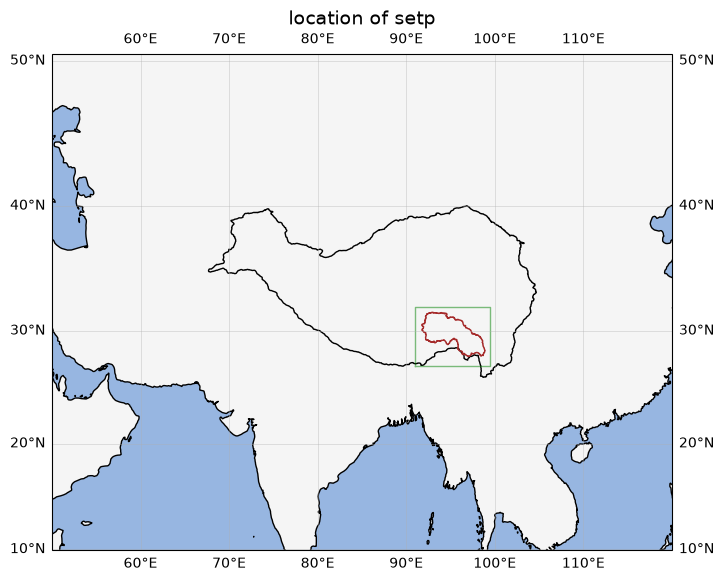

In [ ]:
region_x = [91, 99.5, 99.5, 91, 91]
region_y = [27, 27, 32, 32, 27]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator(central_longitude=88.5))
# ax.stock_img()
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.LAND, facecolor='WhiteSmoke')
ax.add_feature(cfeature.COASTLINE, edgecolor='Black')
ax.set_extent([50, 120, 10, 45.0])
# # 1. hma region
tp_gdf.plot(ax=ax, transform=ccrs.PlateCarree(), 
             facecolor='none', edgecolor='black', linewidth=1)
setp_vec.plot(ax=ax, transform=ccrs.PlateCarree(), 
             facecolor='none', edgecolor='brown', linewidth=1)

# 2. rectangle region of the study area.
ax.plot(region_x, region_y, transform=ccrs.PlateCarree(), 
                                linewidth=1, color='green', alpha=0.5)

ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax.set_title('location of setp', fontsize=14)
# fig.savefig('figs/1_tp_region.png', dpi=300, bbox_inches='tight')



In [6]:
### define dem cmap
colors_1 = [(128/255, 205/255, 193/255), 
          (245/255, 245/255, 245/255),
          (223/255, 194/255, 125/255), 
          (166/255, 97/255, 26/255)]
colors_2 = [
    (65/255, 105/255, 225/255),   # 深湖蓝 (<3000m)
    # (173/255, 216/255, 230/255),  # 淡蓝色 (<3000m)
    (230/255, 220/255, 170/255),  # 草甸金 (3000-4000m)
    (210/255, 180/255, 140/255),  # 荒漠黄 (4000-4800m)
    (185/255, 150/255, 120/255),  # 丘陵棕 (4800-5200m)
    (150/255, 120/255, 100/255),  # 山地褐 (5200-5500m)
    (180/255, 175/255, 170/255),  # 裸岩灰 (5500-5800m)
    (210/255, 210/255, 210/255),  # 积雪灰 (5800-6200m)
    (245/255, 245/255, 245/255)   # 冰川白 (>6200m)
]
cmap_dem = LinearSegmentedColormap.from_list('linear color', colors_1)


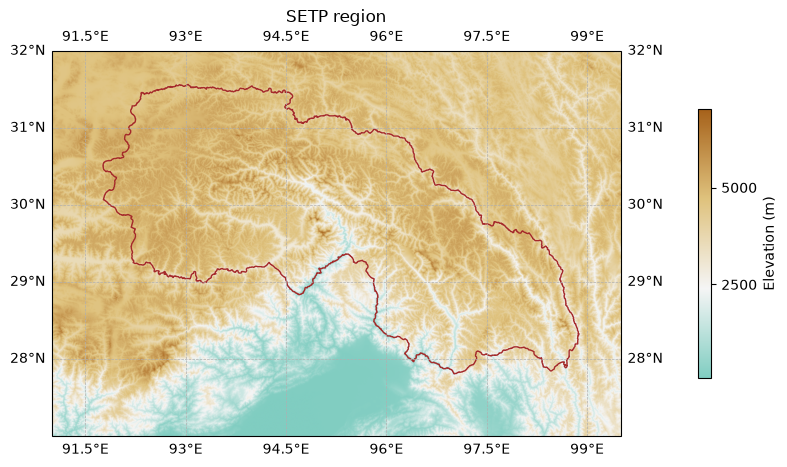

In [12]:
fig, ax = plt.subplots(figsize=(10, 5), 
                       subplot_kw={'projection': ccrs.PlateCarree()})
# ax.set_extent([64,107,24,45.5])
im_show = ax.imshow(dem_arr, cmap=cmap_dem, extent=dem_extent)
setp_vec.plot(ax=ax, transform=ccrs.PlateCarree(), 
             facecolor='none', edgecolor='brown', linewidth=1)
ax.set_title('SETP region', fontsize=12)
fig.colorbar(im_show, ax=ax, orientation='vertical',pad=0.1,
             label='Elevation (m)', shrink=0.7, ticks=[0, 2500, 5000, 7500])
## add names of subregions
ax.gridlines(draw_labels=True, linestyle='--', linewidth=0.5),
fig.savefig('figs/2_setp_region.png', dpi=300, bbox_inches='tight')
